In [2]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
from spatial_manifolds.anaylsis_parameters import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline


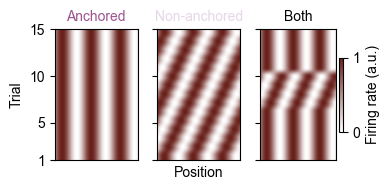

In [3]:
# --- Composite plot: Anchored, Non-anchored, and hybrid sequence ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import find_peaks

# Parameters
track_length = 200  # cm
n_trials = 15
n_bins = 400
period = 70  # grid spacing in cm
trial_positions = np.linspace(0, track_length, n_bins)

# Colors
col_ta = "#9d5391"   # Task-anchored
col_nta = "#e7d7e8"  # Non-task-anchored
black_cmap = LinearSegmentedColormap.from_list('black_cmap', ['white', gc_color_dark])

# Task-anchored
ta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    ta_map[t] = np.sin(2 * np.pi * trial_positions / period)
ta_map = (ta_map - ta_map.min()) / (ta_map.max() - ta_map.min())

# Non-task-anchored
nta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    nta_map[t] = np.sin(2 * np.pi * (trial_positions + t * track_length) / period)
nta_map = (nta_map - nta_map.min()) / (nta_map.max() - nta_map.min())

# Hybrid: 5 anchored, 5 non-anchored, 5 anchored (total 15 trials)
hybrid_trials = 15
hybrid_map = np.zeros((hybrid_trials, n_bins))
for t in range(5):
    hybrid_map[t] = np.sin(2 * np.pi * trial_positions / period)  # anchored
for t in range(5, 10):
    hybrid_map[t] = np.sin(2 * np.pi * (trial_positions + (t-5) * track_length) / period)  # non-anchored
for t in range(10, 15):
    hybrid_map[t] = np.sin(2 * np.pi * trial_positions / period)  # anchored
hybrid_map = (hybrid_map - hybrid_map.min()) / (hybrid_map.max() - hybrid_map.min())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(4, 2), sharey=True)

# Task-anchored (left)
im0 = axes[0].imshow(ta_map, aspect='auto', cmap=black_cmap,
                    vmin=0, vmax=1, origin='lower',
                    extent=[0, track_length, 1, n_trials])
axes[0].set_title('Anchored', color=col_ta, fontsize=10)
axes[0].set_ylabel('Trial')
axes[0].set_xticks([])
axes[0].set_yticks([1, 5, 10, 15])
'''# Add vertical lines at firing field peaks
peaks, _ = find_peaks(ta_map[0], height=0.7)
peak_positions = trial_positions[peaks]
for xpos in peak_positions:
    axes[0].axvline(xpos, color=col_ta, lw=2, alpha=0.9, zorder=10)
'''
# Non-task-anchored (middle)
im1 = axes[1].imshow(nta_map, aspect='auto', cmap=black_cmap,
                    vmin=0, vmax=1, origin='lower',
                    extent=[0, track_length, 1, n_trials])
axes[1].set_title('Non-anchored', color=col_nta, fontsize=10)
axes[1].set_xlabel('Position')
axes[1].set_xticks([])
axes[1].set_yticks([1, 5, 10, 15])

# Hybrid (right)
im2 = axes[2].imshow(hybrid_map, aspect='auto', cmap=black_cmap,
                    vmin=0, vmax=1, origin='lower',
                    extent=[0, track_length, 1, hybrid_trials])
axes[2].set_title('Both', fontsize=10)
axes[2].set_xticks([])
axes[2].set_yticks([1, 5, 10, 15])
'''# Add vertical lines at firing field peaks only within the anchored trials
peaks, _ = find_peaks(hybrid_map[0], height=0.7)
peak_positions = trial_positions[peaks]
for xpos in peak_positions:
    axes[2].axvline(xpos, color=col_ta, lw=2, alpha=0.9, zorder=10, ymin=0, ymax=5/hybrid_trials)
peaks_end, _ = find_peaks(hybrid_map[-1], height=0.7)
peak_positions_end = trial_positions[peaks_end]
for xpos in peak_positions_end:
    axes[2].axvline(xpos, color=col_ta, lw=2, alpha=0.9, zorder=10, ymin=10/hybrid_trials, ymax=15/hybrid_trials)
'''
# Colorbar for the rightmost plot
cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.045, pad=0.04)
cbar2.set_ticks([0,1])
cbar2.set_label('Firing rate (a.u.)')

plt.tight_layout()
plt.savefig('task_anchoring_schematic.pdf', dpi=300)
plt.show()


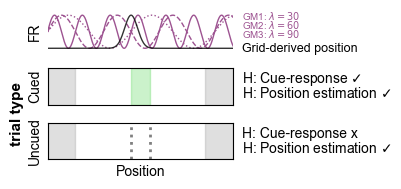

In [4]:
# --- Grid cells and track cues: 3-row plot with annotations ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

track_length = 200
x = np.linspace(0, track_length, 400)
periods = [30, 60, 90]
alphas = [0.9, 0.6, 0.3]
colors = ['#9d5391', '#9d5391', '#9d5391']
thickness = [1,1,1]

fig, axes = plt.subplots(3, 1, figsize=(4, 2), sharex=True, gridspec_kw={'height_ratios': [0.7, 0.7, 0.7]})

# Row 1: grid cell firing rates
linestyles = ['-', '--', ':']
for i, (p, c, t, a, ls) in enumerate(zip(periods, colors, thickness, alphas, linestyles)):
    y = np.sin(2 * np.pi * x / p)
    y = (y - y.min()) / (y.max() - y.min())
    axes[0].plot(x, y, label=f'Period {p} cm', color=c, lw=t, ls=ls)

# Add Gaussian (black) centered at 90
mu = 90
sigma = 7
G = norm.pdf(x, mu, sigma)
G = G / G.max()  # normalize to 1
axes[0].plot(x, G, color='black', lw=1, alpha=0.8, label='Gaussian @ 90')

axes[0].set_xlim(0, 200)
axes[0].set_yticks([])
axes[0].set_xticks([])
axes[0].set_ylabel('FR')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)

# Manual legend using axes[0].text
axes[0].text(1.05, 1.1, r'GM1: $\lambda=30$', color=colors[0], fontsize=7, alpha=1, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.85, r'GM2: $\lambda=60$', color=colors[1], fontsize=7, alpha=1, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.6, r'GM3: $\lambda=90$', color=colors[2], fontsize=7, alpha=1, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.2, r'Grid-derived position', color='black', fontsize=9, transform=axes[0].transAxes, va='top')

# Row 2: cued track (reward zone)
axes[1].fill_betweenx([0, 1], 90, 110, color='limegreen', alpha=0.25, zorder=0)
axes[1].fill_betweenx([0, 1], 0, 30, color='grey', alpha=0.25, zorder=0)
axes[1].fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
axes[1].set_xlim(0, 200)
axes[1].set_ylim(0, 1)
axes[1].set_yticks([])
axes[1].set_ylabel('Cued')

# Row 3: non-cued track (dotted lines)
axes[2].axvline(90, color='grey', ls=':', lw=2)
axes[2].axvline(110, color='grey', ls=':', lw=2)
axes[2].fill_betweenx([0, 1], 0, 30, color='grey', alpha=0.25, zorder=0)
axes[2].fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
axes[2].set_xlim(0, 200)
axes[2].set_ylim(0, 1)
axes[2].set_yticks([])
axes[2].set_ylabel('Uncued')
axes[2].set_xlabel('Position')

# Add 'trial type' label to the left, centered between cued and uncued
fig.text(0.01, 0.4, 'trial type', va='center', ha='center', rotation='vertical', fontsize=11, fontweight='bold')

# Add right-side annotations with a tick (✓) using Unicode
axes[1].text(1.05, 0.7, 'H: Cue-response $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[1].transAxes, color='black')
axes[1].text(1.05, 0.3, 'H: Position estimation $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[1].transAxes, color='black')

axes[2].text(1.05, 0.7, 'H: Cue-response x', va='center', ha='left', fontsize=10, transform=axes[2].transAxes, color='black')
axes[2].text(1.05, 0.3, 'H: Position estimation $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[2].transAxes, color='black')

plt.tight_layout()
plt.savefig('task_anchoring_schematic_annotated.pdf', dpi=300)
plt.show()


In [ ]:

# --- Grid cells, ramp cells, and track cues: 4-row plot with annotations ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

track_length = 200
x = np.linspace(0, track_length, 400)
periods = [30, 60, 90]
colors = ['#9d5391', '#9d5391', '#9d5391']

fig, axes = plt.subplots(4, 1, figsize=(4, 2.7), sharex=True,
                         gridspec_kw={'height_ratios': [0.7, 0.7, 0.7, 0.7]})

# Row 0: grid cell firing rates
linestyles = ['-', '--', ':']
for i, (p, c, ls) in enumerate(zip(periods, colors, linestyles)):
    y = np.sin(2 * np.pi * x / p)
    y = (y - y.min()) / (y.max() - y.min())
    axes[0].plot(x, y, color=c, lw=1, ls=ls)

mu, sigma = 90, 7
G = norm.pdf(x, mu, sigma)
G = G / G.max()
axes[0].plot(x, G, color='black', lw=1, alpha=0.8)

axes[0].set_xlim(0, 200)
axes[0].set_yticks([])
axes[0].set_xticks([])
axes[0].set_ylabel('GC FR')
for sp in ['top', 'right', 'left', 'bottom']:
    axes[0].spines[sp].set_visible(False)

axes[0].text(1.05, 1.1, r'GM1: $\lambda=30$', color=colors[0], fontsize=7, alpha=1, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.85, r'GM2: $\lambda=60$', color=colors[1], fontsize=7, alpha=1, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.6, r'GM3: $\lambda=90$', color=colors[2], fontsize=7, alpha=1, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.2, r'Grid-derived position', color='black', fontsize=9, transform=axes[0].transAxes, va='top')

# Row 1: ramp cell firing rate (sawtooth, anchored to task)
half_track = track_length / 2
ramp = (x % half_track) / half_track
axes[1].plot(x, ramp, color=ngs_color_dark, lw=1.5)
axes[1].set_xlim(0, 200)
axes[1].set_yticks([])
axes[1].set_xticks([])
axes[1].set_ylabel('NGS FR')
for sp in ['top', 'right', 'left', 'bottom']:
    axes[1].spines[sp].set_visible(False)

axes[1].text(1.05, 0.5, r'NGS ramp cell', color=ngs_color_dark, fontsize=9, transform=axes[1].transAxes, va='center')

# Row 2: cued track (reward zone)
axes[2].fill_betweenx([0, 1], 90, 110, color='limegreen', alpha=0.25, zorder=0)
axes[2].fill_betweenx([0, 1], 0, 30, color='grey', alpha=0.25, zorder=0)
axes[2].fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
axes[2].set_xlim(0, 200)
axes[2].set_ylim(0, 1)
axes[2].set_yticks([])
axes[2].set_ylabel('Cued')

axes[2].text(1.05, 0.7, r'H: Cue-response $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[2].transAxes, color='black')
axes[2].text(1.05, 0.3, r'H: Position estimation $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[2].transAxes, color='black')

# Row 3: uncued track (dotted lines)
axes[3].axvline(90, color='grey', ls=':', lw=2)
axes[3].axvline(110, color='grey', ls=':', lw=2)
axes[3].fill_betweenx([0, 1], 0, 30, color='grey', alpha=0.25, zorder=0)
axes[3].fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
axes[3].set_xlim(0, 200)
axes[3].set_ylim(0, 1)
axes[3].set_yticks([])
axes[3].set_ylabel('Uncued')
axes[3].set_xlabel('Position')

axes[3].text(1.05, 0.7, 'H: Cue-response x', va='center', ha='left', fontsize=10, transform=axes[3].transAxes, color='black')
axes[3].text(1.05, 0.3, r'H: Position estimation $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[3].transAxes, color='black')

fig.text(0.01, 0.35, 'trial type', va='center', ha='center', rotation='vertical', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('task_anchoring_schematic_annotated_v2.pdf', dpi=300)
plt.show()


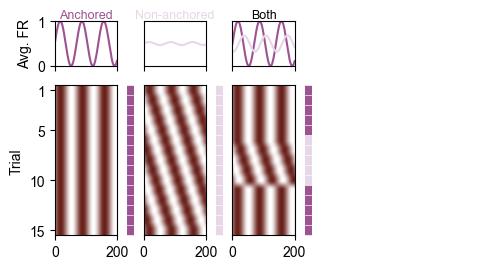

In [5]:
# --- Composite plot: average rates row + imshows with scatter labels ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import find_peaks

# Parameters
track_length = 200
n_trials = 15
n_bins = 400
period = 70
trial_positions = np.linspace(0, track_length, n_bins)

# Colors
col_ta  = "#9d5391"   # task-anchored (purple)
col_nta = "#e7d7e8"   # non-task-anchored (grey) for scatter/rates
black_cmap = LinearSegmentedColormap.from_list('black_cmap', ['white', gc_color_dark])

# Task-anchored map
ta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    ta_map[t] = np.sin(2 * np.pi * trial_positions / period)
ta_map = (ta_map - ta_map.min()) / (ta_map.max() - ta_map.min())

# Non-task-anchored map
nta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    nta_map[t] = np.sin(2 * np.pi * (trial_positions + t * track_length) / period)
nta_map = (nta_map - nta_map.min()) / (nta_map.max() - nta_map.min())

# Hybrid: 5 anchored, 5 non-anchored, 5 anchored
hybrid_map = np.zeros((n_trials, n_bins))
for t in range(5):
    hybrid_map[t] = np.sin(2 * np.pi * trial_positions / period)
for t in range(5, 10):
    hybrid_map[t] = np.sin(2 * np.pi * (trial_positions + (t - 5) * track_length) / period)
for t in range(10, 15):
    hybrid_map[t] = np.sin(2 * np.pi * trial_positions / period)
hybrid_map = (hybrid_map - hybrid_map.min()) / (hybrid_map.max() - hybrid_map.min())

# Average rates
ta_avg  = ta_map.mean(axis=0)
nta_avg = nta_map.mean(axis=0)
hybrid_anch_idx    = list(range(5)) + list(range(10, 15))
hybrid_nonanch_idx = list(range(5, 10))
hybrid_avg_anch    = hybrid_map[hybrid_anch_idx].mean(axis=0)
hybrid_avg_nonanch = hybrid_map[hybrid_nonanch_idx].mean(axis=0)

scatter_y     = np.arange(n_trials)
imshow_extent = [0, track_length, -0.5, n_trials - 0.5]

# Layout params
n_cols = 10
width_ratios = [1, 0.1, 1, 0.1, 1, 0.1, 1, 0.1, 1, 0.1]
rm_figsize = (1, 1.8)

fig, axes = plt.subplots(
    nrows=2, ncols=n_cols,
    figsize=(rm_figsize[0] * 5.6, rm_figsize[1] * 1.7),
    gridspec_kw={'height_ratios': [0.3, 1], 'width_ratios': width_ratios},
)

# Turn off spines on narrow cols (1, 3, 5) in both rows
narrow_cols = [1, 3, 5]
for row in range(2):
    for col in narrow_cols:
        for spine in axes[row, col].spines.values():
            spine.set_visible(False)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

# --- Row 0: Average rates (cols 0, 2, 4 — spines kept) ---
axes[0, 0].plot(trial_positions, ta_avg, color=col_ta, lw=1.5)
axes[0, 0].set_title('Anchored', color=col_ta, pad=2, fontsize=9)

axes[0, 2].plot(trial_positions, nta_avg, color=col_nta, lw=1.5)
axes[0, 2].set_title('Non-anchored', color=col_nta, pad=2, fontsize=9)
axes[0, 2].set_xticks([]); axes[0, 2].set_yticks([])

axes[0, 4].plot(trial_positions, hybrid_avg_anch,    color=col_ta,  lw=1.5, label='Anchored')
axes[0, 4].plot(trial_positions, hybrid_avg_nonanch, color=col_nta, lw=1.5, label='Non-anch.')
axes[0, 4].set_title('Both', pad=2, fontsize=9)
axes[0, 4].set_xticks([]); axes[0, 4].set_yticks([])

# --- Row 1: Imshows (cols 0, 2, 4 — spines kept) ---
axes[1, 0].imshow(ta_map, aspect='auto', cmap=black_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 0].set_ylabel('Trial')
axes[1, 0].set_yticks([0, 4, 9, 14])
axes[1, 0].set_yticklabels([1, 5, 10, 15])
axes[1, 0].set_xticks([])
axes[0, 1]
axes[1, 0].set_ylim(-0.5, n_trials - 0.5)
axes[1, 2].imshow(nta_map, aspect='auto', cmap=black_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 2].set_xticks([]); axes[1, 2].set_yticks([])

axes[1, 4].imshow(hybrid_map, aspect='auto', cmap=black_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 4].set_xticks([]); axes[1, 4].set_yticks([])

# --- Row 1: Scatter columns (cols 1, 3, 5 — spines already off) ---
axes[1, 1].set_xlim(-0.5, 0.5); axes[1, 1].set_ylim(-0.5, n_trials - 0.5)
axes[1, 3].set_xlim(-0.5, 0.5); axes[1, 3].set_ylim(-0.5, n_trials - 0.5)
axes[1, 5].set_xlim(-0.5, 0.5); axes[1, 5].set_ylim(-0.5, n_trials - 0.5)

# All anchored (purple)
axes[1, 1].scatter(np.zeros(n_trials), scatter_y, color=col_ta, s=30, zorder=5, marker='s')

# All non-anchored (grey)
axes[1, 3].scatter(np.zeros(n_trials), scatter_y, color=col_nta, s=30, zorder=5, marker='s')

# Mixed: anchored purple, non-anchored grey
axes[1, 5].scatter(
    np.zeros(len(hybrid_anch_idx)), scatter_y[hybrid_anch_idx],
    color=col_ta, s=30, zorder=5, marker='s'
)
axes[1, 5].scatter(
    np.zeros(len(hybrid_nonanch_idx)), scatter_y[hybrid_nonanch_idx],
    color=col_nta, s=30, zorder=5, marker='s'
)

axes[0,-1].axis('off')  # turn off the last narrow column in the top row
axes[0,-2].axis('off')  # turn off the last narrow column in the top row
axes[0,-3].axis('off')  # turn off the last narrow column in the top row
axes[0,-4].axis('off')  # turn off the last narrow column in the top row
axes[1,-1].axis('off')  # turn off the last narrow column in the top row
axes[1,-2].axis('off')  # turn off the last narrow column in the top row
axes[1,-3].axis('off')  # turn off the last narrow column in the top row
axes[1,-4].axis('off')  # turn off the last narrow column in the top row

axes[1,0].set_yticks([1,5,10,15])
axes[1,0].set_yticklabels([1,5,10,15])
axes[1,0].set_ylim(1,n_trials+1)
axes[1,0].set_xticks([0,200])
axes[1,0].set_xticks([0,200])
axes[1,2].set_xticks([0,200])
axes[1,4].set_xticks([0,200])

axes[0,0].set_xticks([0,200]); axes[0,0].set_xticklabels([])
axes[0,2].set_xticks([0,200]); axes[0,2].set_xticklabels([])
axes[0,4].set_xticks([0,200]); axes[0,4].set_xticklabels([])

axes[0,0].set_ylim(0, 1)
axes[0,2].set_ylim(0, 1)
axes[0,4].set_ylim(0, 1)

axes[1,0].set_ylim(-0.5, n_trials-0.5)
axes[1,0].set_yticks([0, 4, 9, 14])
axes[1,0].set_yticklabels([1, 5, 10, 15])
axes[0,0].set_xlim(0, track_length)
axes[0,2].set_xlim(0, track_length)
axes[0,4].set_xlim(0, track_length)
axes[1,0].invert_yaxis()
axes[1,2].invert_yaxis()
axes[1,4].invert_yaxis()
axes[0,0].set_ylabel('Avg. FR')
plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)  # increase bottom margin
plt.savefig('task_anchoring_schematic_v2.pdf', dpi=300, bbox_inches='tight')
plt.show()

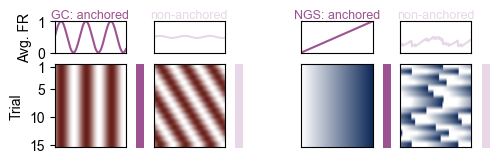

In [6]:
# --- Composite plot: grid cells + ramp cells ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

rng = np.random.default_rng(42)

# Parameters
track_length = 200
n_trials = 15
n_bins = 400
period = 70
trial_positions = np.linspace(0, track_length, n_bins)

# Colors
col_ta   = "#9d5391"
col_nta  = "#e7d7e8"
col_ramp = ngs_color_dark   # blue for ramp cell imshow
black_cmap = LinearSegmentedColormap.from_list('black_cmap', ['white', gc_color_dark])
ramp_cmap  = LinearSegmentedColormap.from_list('ramp_cmap',  ['white', ngs_color_dark])

# --- Grid cell maps ---
ta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    ta_map[t] = np.sin(2 * np.pi * trial_positions / period)
ta_map = (ta_map - ta_map.min()) / (ta_map.max() - ta_map.min())

nta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    nta_map[t] = np.sin(2 * np.pi * (trial_positions + t * track_length) / period)
nta_map = (nta_map - nta_map.min()) / (nta_map.max() - nta_map.min())

# --- Ramp cell maps ---
# Anchored ramp: linear 0→1 over full track (0→200 cm), identical every trial
linear_ramp = trial_positions / track_length
ta_ramp_map = np.tile(linear_ramp, (n_trials, 1))

# Non-anchored ramp: sawtooth — ramps 0→1 over ramp_width cm, then silent,
# repeated with a random phase offset each trial
ramp_width = 90   # cm over which firing ramps 0→1
silence    = 40   # cm of zero firing after each ramp
cycle      = ramp_width + silence   # 130 cm total cycle (~1.5 cycles per 200 cm)

nta_ramp_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    phase = rng.uniform(0, cycle)          # random starting position in the cycle
    x_shifted = (trial_positions + phase) % cycle
    ramp = x_shifted / ramp_width
    ramp[x_shifted >= ramp_width] = 0     # silence during the gap
    nta_ramp_map[t] = ramp

# Average rates
ta_avg       = ta_map.mean(axis=0)
nta_avg      = nta_map.mean(axis=0)
ta_ramp_avg  = ta_ramp_map.mean(axis=0)
nta_ramp_avg = nta_ramp_map.mean(axis=0)

scatter_y     = np.arange(n_trials)
imshow_extent = [0, track_length, -0.5, n_trials - 0.5]

# Layout: 10 cols — cols 4,5 spacer gap; cols 6,8 ramp imshows; cols 7,9 scatter
n_cols = 10
width_ratios = [1, 0.1, 1, 0.1, 0.3, 0.1, 1, 0.1, 1, 0.1]
rm_figsize = (1, 1.8)

fig, axes = plt.subplots(
    nrows=2, ncols=n_cols,
    figsize=(rm_figsize[0] * 5.6, rm_figsize[1] * 1),
    gridspec_kw={'height_ratios': [0.3, 0.8], 'width_ratios': width_ratios},
)

# Turn off spines on narrow/scatter cols
narrow_cols = [1, 3, 7, 9]
for row in range(2):
    for col in narrow_cols:
        for spine in axes[row, col].spines.values():
            spine.set_visible(False)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

# Turn off gap cols 4 and 5
for row in range(2):
    axes[row, 4].axis('off')
    axes[row, 5].axis('off')

# --- Row 0: Average rates ---
axes[0, 0].plot(trial_positions, ta_avg, color=col_ta, lw=1.5)
axes[0, 0].set_title('GC: anchored', color=col_ta, pad=2, fontsize=9)
axes[0, 0].set_xticks([0, 200]); axes[0, 0].set_xticklabels([])
axes[0, 0].set_ylim(0, 1); axes[0, 0].set_xlim(0, track_length)
axes[0, 0].set_ylabel('Avg. FR')

axes[0, 2].plot(trial_positions, nta_avg, color=col_nta, lw=1.5)
axes[0, 2].set_title('non-anchored', color=col_nta, pad=2, fontsize=9)
axes[0, 2].set_xticks([0, 200]); axes[0, 2].set_xticklabels([])
axes[0, 2].set_yticks([])
axes[0, 2].set_ylim(0, 1); axes[0, 2].set_xlim(0, track_length)

axes[0, 6].plot(trial_positions, ta_ramp_avg, color=col_ta, lw=1.5)
axes[0, 6].set_title('NGS: anchored', color=col_ta, pad=2, fontsize=9)
axes[0, 6].set_xticks([0, 200]); axes[0, 6].set_xticklabels([])
axes[0, 6].set_yticks([])
axes[0, 6].set_ylim(0, 1); axes[0, 6].set_xlim(0, track_length)

axes[0, 8].plot(trial_positions, nta_ramp_avg, color=col_nta, lw=1.5)
axes[0, 8].set_title('non-anchored', color=col_nta, pad=2, fontsize=9)
axes[0, 8].set_xticks([0, 200]); axes[0, 8].set_xticklabels([])
axes[0, 8].set_yticks([])
axes[0, 8].set_ylim(0, 1); axes[0, 8].set_xlim(0, track_length)

# --- Row 1: Imshows (grid = black_cmap, ramp = ramp_cmap/blue) ---
axes[1, 0].imshow(ta_map, aspect='auto', cmap=black_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 0].set_ylabel('Trial')
axes[1, 0].set_yticks([0, 4, 9, 14])
axes[1, 0].set_yticklabels([1, 5, 10, 15])
axes[1, 0].set_xticks([0, 200])
axes[1, 0].set_ylim(-0.5, n_trials - 0.5)
axes[1, 0].invert_yaxis()

axes[1, 2].imshow(nta_map, aspect='auto', cmap=black_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 2].set_xticks([0, 200]); axes[1, 2].set_yticks([])
axes[1, 2].invert_yaxis()

axes[1, 6].imshow(ta_ramp_map, aspect='auto', cmap=ramp_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 6].set_xticks([0, 200]); axes[1, 6].set_yticks([])
axes[1, 6].invert_yaxis()

axes[1, 8].imshow(nta_ramp_map, aspect='auto', cmap=ramp_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 8].set_xticks([0, 200]); axes[1, 8].set_yticks([])
axes[1, 8].invert_yaxis()

# --- Row 1: Scatter columns (anchored=purple, non-anchored=grey) ---
for col in [1, 3, 7, 9]:
    axes[1, col].set_xlim(-0.5, 0.5)
    axes[1, col].set_ylim(-0.5, n_trials - 0.5)

for col in [0, 2, 6, 8]:
    axes[1, col].set_xticks([])
    axes[1, col].set_xlim(0, track_length)
    axes[0, col].set_xticks([])

axes[1, 1].scatter(np.zeros(n_trials), scatter_y, color=col_ta,  s=30, zorder=5, marker='s')
axes[1, 3].scatter(np.zeros(n_trials), scatter_y, color=col_nta, s=30, zorder=5, marker='s')
axes[1, 7].scatter(np.zeros(n_trials), scatter_y, color=col_ta,  s=30, zorder=5, marker='s')  # anchored
axes[1, 9].scatter(np.zeros(n_trials), scatter_y, color=col_nta, s=30, zorder=5, marker='s')  # non-anchored

plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
plt.savefig('task_anchoring_schematic_v6_ramp_sawtooth.pdf', dpi=300, bbox_inches='tight')
plt.show()


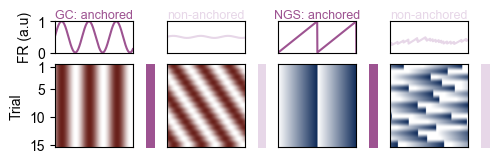

In [7]:

# --- Composite plot: grid cells + ramp cells (no spacer column) ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

rng = np.random.default_rng(42)

# Parameters
track_length = 200
n_trials = 15
n_bins = 400
period = 70
trial_positions = np.linspace(0, track_length, n_bins)

# Colors
col_ta   = "#9d5391"
col_nta  = "#e7d7e8"
black_cmap = LinearSegmentedColormap.from_list('black_cmap', ['white', gc_color_dark])
ramp_cmap  = LinearSegmentedColormap.from_list('ramp_cmap',  ['white', ngs_color_dark])

# --- Grid cell maps ---
ta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    ta_map[t] = np.sin(2 * np.pi * trial_positions / period)
ta_map = (ta_map - ta_map.min()) / (ta_map.max() - ta_map.min())

nta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    nta_map[t] = np.sin(2 * np.pi * (trial_positions + t * track_length) / period)
nta_map = (nta_map - nta_map.min()) / (nta_map.max() - nta_map.min())

# --- Ramp cell maps ---
# Anchored ramp: ramps 0→1 twice per track (sawtooth with period = 100 cm)
half_track = track_length / 2  # 100 cm
ramp = (trial_positions % half_track) / half_track
ta_ramp_map = np.tile(ramp, (n_trials, 1))

# Non-anchored ramp: 100 cm ramp then random-length blank, repeated with random phase per trial
ramp_width = 100
nta_ramp_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    silence = rng.uniform(10, 60)          # random blank length per trial
    cycle = ramp_width + silence
    phase = rng.uniform(0, cycle)          # random starting phase per trial
    x_shifted = (trial_positions + phase) % cycle
    ramp_vals = x_shifted / ramp_width
    ramp_vals[x_shifted >= ramp_width] = 0
    nta_ramp_map[t] = ramp_vals

# Average rates
ta_avg       = ta_map.mean(axis=0)
nta_avg      = nta_map.mean(axis=0)
ta_ramp_avg  = ta_ramp_map.mean(axis=0)
nta_ramp_avg = nta_ramp_map.mean(axis=0)

scatter_y     = np.arange(n_trials)
imshow_extent = [0, track_length, -0.5, n_trials - 0.5]

# Layout: 8 cols — no spacer; cols 0,2,4,6 are imshows; cols 1,3,5,7 are scatters
n_cols = 8
width_ratios = [1, 0.1, 1, 0.1, 1, 0.1, 1, 0.1]
rm_figsize = (1, 1.8)

fig, axes = plt.subplots(
    nrows=2, ncols=n_cols,
    figsize=(rm_figsize[0] * 5.6, rm_figsize[1] * 1),
    gridspec_kw={'height_ratios': [0.3, 0.8], 'width_ratios': width_ratios},
)

# Turn off spines on narrow/scatter cols
narrow_cols = [1, 3, 5, 7]
for row in range(2):
    for col in narrow_cols:
        for spine in axes[row, col].spines.values():
            spine.set_visible(False)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

# --- Row 0: Average rates ---
axes[0, 0].plot(trial_positions, ta_avg, color=col_ta, lw=1.5)
axes[0, 0].set_title('GC: anchored', color=col_ta, pad=2, fontsize=9)
axes[0, 0].set_xticks([0, 200]); axes[0, 0].set_xticklabels([])
axes[0, 0].set_ylim(0, 1); axes[0, 0].set_xlim(0, track_length)
axes[0, 0].set_ylabel('FR (a.u)')
    
axes[0, 2].plot(trial_positions, nta_avg, color=col_nta, lw=1.5)
axes[0, 2].set_title('non-anchored', color=col_nta, pad=2, fontsize=9)
axes[0, 2].set_xticks([0, 200]); axes[0, 2].set_xticklabels([])
axes[0, 2].set_yticks([])
axes[0, 2].set_ylim(0, 1); axes[0, 2].set_xlim(0, track_length)

axes[0, 4].plot(trial_positions, ta_ramp_avg, color=col_ta, lw=1.5)
axes[0, 4].set_title('NGS: anchored', color=col_ta, pad=2, fontsize=9)
axes[0, 4].set_xticks([0, 200]); axes[0, 4].set_xticklabels([])
axes[0, 4].set_yticks([])
axes[0, 4].set_ylim(0, 1); axes[0, 4].set_xlim(0, track_length)

axes[0, 6].plot(trial_positions, nta_ramp_avg, color=col_nta, lw=1.5)
axes[0, 6].set_title('non-anchored', color=col_nta, pad=2, fontsize=9)
axes[0, 6].set_xticks([0, 200]); axes[0, 6].set_xticklabels([])
axes[0, 6].set_yticks([])
axes[0, 6].set_ylim(0, 1); axes[0, 6].set_xlim(0, track_length)

# --- Row 1: Imshows (grid = black_cmap, ramp = ramp_cmap) ---
axes[1, 0].imshow(ta_map, aspect='auto', cmap=black_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 0].set_ylabel('Trial')
axes[1, 0].set_yticks([0, 4, 9, 14])
axes[1, 0].set_yticklabels([1, 5, 10, 15])
axes[1, 0].set_xticks([0, 200])
axes[1, 0].set_ylim(-0.5, n_trials - 0.5)
axes[1, 0].invert_yaxis()

axes[1, 2].imshow(nta_map, aspect='auto', cmap=black_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 2].set_xticks([0, 200]); axes[1, 2].set_yticks([])
axes[1, 2].invert_yaxis()

axes[1, 4].imshow(ta_ramp_map, aspect='auto', cmap=ramp_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 4].set_xticks([0, 200]); axes[1, 4].set_yticks([])
axes[1, 4].invert_yaxis()

axes[1, 6].imshow(nta_ramp_map, aspect='auto', cmap=ramp_cmap, vmin=0, vmax=1,
                  origin='lower', extent=imshow_extent)
axes[1, 6].set_xticks([0, 200]); axes[1, 6].set_yticks([])
axes[1, 6].invert_yaxis()

# --- Row 1: Scatter columns ---
for col in [1, 3, 5, 7]:
    axes[1, col].set_xlim(-0.5, 0.5)
    axes[1, col].set_ylim(-0.5, n_trials - 0.5)

for col in [0, 2, 4, 6]:
    axes[1, col].set_xticks([])
    axes[1, col].set_xlim(0, track_length)
    axes[0, col].set_xticks([])

axes[1, 1].scatter(np.zeros(n_trials), scatter_y, color=col_ta,  s=30, zorder=5, marker='s')
axes[1, 3].scatter(np.zeros(n_trials), scatter_y, color=col_nta, s=30, zorder=5, marker='s')
axes[1, 5].scatter(np.zeros(n_trials), scatter_y, color=col_ta,  s=30, zorder=5, marker='s')
axes[1, 7].scatter(np.zeros(n_trials), scatter_y, color=col_nta, s=30, zorder=5, marker='s')

plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
plt.savefig('task_anchoring_schematic_v7_no_spacer.pdf', dpi=300)
plt.show()


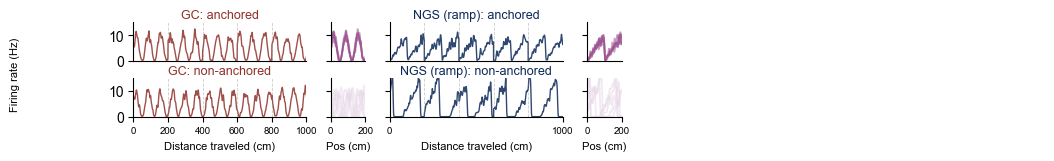

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

rng = np.random.default_rng(4)

# ── Parameters ────────────────────────────────────────────────────────────
track_length    = 200
n_trials        = 5
n_bins          = 400
period          = 70
half_track      = track_length / 2
ramp_width      = 100
bin_width       = track_length / n_bins   # 0.5 cm / bin
sigma_bins      = 2.0 / bin_width         # Gaussian SD = 2 cm → 4 bins
mean_spikes     = 1000
trial_positions = np.linspace(0, track_length, n_bins)
x_unrav         = np.linspace(0, n_trials * track_length, n_trials * n_bins)

# Column 0 & 2 (unravelled): distinct colour per cell type, same across rows
col_gc_unrav   = '#90312a'
col_ngs_unrav  = ngs_color_dark
# Columns 1 & 3 (overlaid): anchored / non-anchored
col_ov_anch    = '#9d5391'
col_ov_nonanch = '#e7d7e8'

# ── Helpers ───────────────────────────────────────────────────────────────
def _make_profile(y):
    mn, mx = y.min(), y.max()
    return (y - mn) / (mx - mn) if mx > mn else y

def _sample_and_reconstruct(rate_profile, rng_obj):
    pdf  = rate_profile / rate_profile.sum()
    n_sp = rng_obj.poisson(mean_spikes)
    if n_sp == 0:
        return np.zeros(len(rate_profile))
    spike_idx = rng_obj.choice(len(pdf), size=n_sp, p=pdf)
    counts, _ = np.histogram(spike_idx, bins=np.arange(len(pdf) + 1) - 0.5)
    fr = counts.astype(float) / bin_width
    return gaussian_filter1d(fr, sigma=sigma_bins)

def _reconstruct_all(profiles, rng_obj):
    return [_sample_and_reconstruct(p, rng_obj) for p in profiles]

def _plot_unravelled(ax, frs, color, title, ylabel=None, show_xaxis=False):
    """Concatenate all trials into one continuous trace (0 → n_trials*200 cm)."""
    fr_cat = np.concatenate(frs)
    ax.plot(x_unrav, fr_cat, color=color, alpha=0.85, lw=1.0)
    for t in range(1, n_trials):
        ax.axvline(t * track_length, color='grey', lw=0.6, ls='--', alpha=0.4)
    ax.set_title(title, color=color, fontsize=9, pad=3)
    ax.set_xlim(0, n_trials * track_length)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8)
    if show_xaxis:
        ax.set_xticks([0, n_trials * track_length])
        ax.set_xticklabels(['0', f'{n_trials * track_length}'], fontsize=7)
        ax.set_xlabel('Distance traveled (cm)', fontsize=8)
    else:
        ax.set_xticks([])

def _plot_overlaid(ax, frs, color, title, ylabel=None, show_xaxis=False):
    """Overlay each trial's FR on 0–200 cm axes."""
    for fr in frs:
        ax.plot(trial_positions, fr, color=color, alpha=0.55, lw=1.2)
    ax.set_title(title, color=color, fontsize=9, pad=3)
    ax.set_xlim(0, track_length)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8)
    if show_xaxis:
        ax.set_xticks([0, track_length])
        ax.set_xticklabels(['0', f'{track_length}'], fontsize=7)
        ax.set_xlabel('Pos (cm)', fontsize=8)
    else:
        ax.set_xticks([])

# ── Rate profiles ─────────────────────────────────────────────────────────
gc_anch_profiles = [
    _make_profile(np.sin(2 * np.pi * trial_positions / period))
    for _ in range(n_trials)
]
gc_nonanch_profiles = [
    _make_profile(np.sin(2 * np.pi * (trial_positions + t * track_length) / period))
    for t in range(n_trials)
]

sawtooth = (trial_positions % half_track) / half_track
ngs_anch_profiles = [sawtooth.copy() for _ in range(n_trials)]

ngs_nonanch_profiles = []
for _ in range(n_trials):
    silence = rng.uniform(10, 60)
    cycle   = ramp_width + silence
    phase   = rng.uniform(0, cycle)
    xs      = (trial_positions + phase) % cycle
    rv      = xs / ramp_width
    rv[xs >= ramp_width] = 0
    ngs_nonanch_profiles.append(rv.copy())

# Reconstruct once; shared by both unravelled and overlaid views
gc_anch_frs     = _reconstruct_all(gc_anch_profiles,     rng)
gc_nonanch_frs  = _reconstruct_all(gc_nonanch_profiles,  rng)
ngs_anch_frs    = _reconstruct_all(ngs_anch_profiles,    rng)
ngs_nonanch_frs = _reconstruct_all(ngs_nonanch_profiles, rng)

# ── Figure: 2 rows × 5 cols ───────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=2, ncols=5,
    figsize=(rm_figsize[0] * 11.75, rm_figsize[1] * 0.75),
    width_ratios=[5, 1, 5, 1, 11.5],
    sharey='row',
)

# Row 0: anchored
_plot_unravelled(axes[0, 0], gc_anch_frs,    col_gc_unrav,  'GC: anchored',
                 show_xaxis=False)
_plot_overlaid(  axes[0, 1], gc_anch_frs,    col_ov_anch,   '',
                 show_xaxis=False)
_plot_unravelled(axes[0, 2], ngs_anch_frs,   col_ngs_unrav, 'NGS (ramp): anchored',
                 show_xaxis=False)
_plot_overlaid(  axes[0, 3], ngs_anch_frs,   col_ov_anch,   '',
                 show_xaxis=False)

# Row 1: non-anchored
_plot_unravelled(axes[1, 0], gc_nonanch_frs,  col_gc_unrav,   'GC: non-anchored',
                 show_xaxis=True)
_plot_overlaid(  axes[1, 1], gc_nonanch_frs,  col_ov_nonanch, '',
                 show_xaxis=True)
_plot_unravelled(axes[1, 2], ngs_nonanch_frs, col_ngs_unrav,  'NGS (ramp): non-anchored',
                 show_xaxis=True)
_plot_overlaid(  axes[1, 3], ngs_nonanch_frs, col_ov_nonanch, '',
                 show_xaxis=True)

axes[0, 4].axis('off')
axes[1, 4].axis('off')
axes[1,0].set_xticks([0, 200, 400, 600, 800, 1000])
axes[1,0].set_xticklabels(['0', '200', '400', '600', '800', '1000'], fontsize=7)
fig.supylabel('Firing rate (Hz)', fontsize=8, )
axes[0, 0].set_ylim(0, 15)
axes[1, 0].set_ylim(0, 15)

plt.subplots_adjust(wspace=0.15, hspace=0.45, bottom=0.18)
plt.savefig('schematic_grid_and_ramp_anchoring.pdf', dpi=300, bbox_inches='tight')
plt.show()